In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

C:\Users\admin\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [5]:
df = pd.read_csv(r'D:\GMSC\transmembrane\secret\disease_ctr.csv')
df['fold_change'] = df['disease_prop']/df['ctr_prop']
df.to_csv(r'D:\GMSC\transmembrane\secret\disease_ctr_fc.tsv',index=None,sep='\t')
df

,Disease,disease_count,disease_secret,disease_prop,ctr_count,ctr_secret,ctr_prop,fold_change
0,Graves' Disease,274,19,0.069343,2562341,134501,0.052491,1.321035
1,ST-elevation myocardial infarction,3054,205,0.067125,2562341,134501,0.052491,1.278781
2,Hypertension,1216,79,0.064967,2562341,134501,0.052491,1.237670
3,Subarachnoid haemorrhage; alcoholism,174,11,0.063218,2562341,134501,0.052491,1.204356
4,cCD,992,62,0.062500,2562341,134501,0.052491,1.190670
...,...,...,...,...,...,...,...,...
74,Barrett's esophagus,644,22,0.034161,2562341,134501,0.052491,0.650801
75,IC,210,7,0.033333,2562341,134501,0.052491,0.635024
76,Aortic aneurysm repair,62,2,0.032258,2562341,134501,0.052491,0.614539
77,"C. diffile infection, admitted to hopsital for...",501,15,0.029940,2562341,134501,0.052491,0.570381


In [8]:
# calculate pvalue
from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency

def cal(infile,outfile):
    out = open(outfile,'wt')
    with open(infile,'rt') as f:
        for line in f:
            if line.startswith('Disease'):
                out.write(f'{line.strip()}\tp_fisher\tp_chi2\n')
            else:
                #print(line.strip().split('\t'))
                disease,disease_count,disease_secret,disease_prop,ctr_count,ctr_secret,ctr_prop,fold_change = line.strip().split('\t')
                disease_secret_count = int(disease_secret)
                ctr_secret_count = int(ctr_secret)
                disease_no_count = int(disease_count)-disease_secret_count
                ctr_no_count = int(ctr_count)-ctr_secret_count
                
                res_fisher = fisher_exact([[disease_secret_count,ctr_secret_count], [disease_no_count, ctr_no_count]])
                res_chi2 = chi2_contingency([[disease_secret_count,ctr_secret_count], [disease_no_count, ctr_no_count]])
                out.write(f'{line.strip()}\t{res_fisher.pvalue}\t{res_chi2.pvalue}\n')
    out.close()

infile = r'D:\GMSC\transmembrane\secret\disease_ctr_fc.tsv'
outfile = r'D:\GMSC\transmembrane\secret\disease_ctr_fc_p.tsv'
cal(infile,outfile)

In [10]:
# p adjust (bonferroni)
from statsmodels.stats.multitest import multipletests
result = pd.read_csv(r'D:\GMSC\transmembrane\secret\disease_ctr_fc_p.tsv',sep='\t')
rejected, p_adjusted, _, alpha_corrected = multipletests(result['p_fisher'], method='bonferroni')
result['p_adjusted_fisher'] = p_adjusted
rejected, p_adjusted, _, alpha_corrected = multipletests(result['p_chi2'], method='bonferroni')
result['p_adjusted_chi2'] = p_adjusted
result.to_csv(r'D:\GMSC\transmembrane\secret\disease_ctr_fc_p_adjust.tsv',index=None,sep='\t')

In [1]:
# calculate pvalue
from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency

def cal(infile,outfile):
    out = open(outfile,'wt')
    with open(infile,'rt') as f:
        for line in f:
            if line.startswith('Disease'):
                out.write(f'{line.strip()}\tp_fisher\tp_chi2\n')
            else:
                #print(line.strip().split('\t'))
                disease,disease_count,disease_secret,disease_prop,ctr_count,ctr_secret,ctr_prop,fold_change = line.strip().split('\t')
                disease_secret_count = int(disease_secret)
                ctr_secret_count = int(ctr_secret)
                disease_no_count = int(disease_count)-disease_secret_count
                ctr_no_count = int(ctr_count)-ctr_secret_count
                
                res_fisher = fisher_exact([[disease_secret_count,ctr_secret_count], [disease_no_count, ctr_no_count]])
                res_chi2 = chi2_contingency([[disease_secret_count,ctr_secret_count], [disease_no_count, ctr_no_count]])
                out.write(f'{line.strip()}\t{res_fisher.pvalue}\t{res_chi2.pvalue}\n')
    out.close()

infile = r'D:\GMSC\transmembrane\secret\al.tsv'
outfile = r'D:\GMSC\transmembrane\secret\al_fc_p.tsv'
cal(infile,outfile)

In [4]:
df = pd.read_csv(r'D:\GMSC\transmembrane\secret\cdi\cdi_pfam_count.tsv',sep='\t')
df['CDI_prop'] = df['CDI_count']/df['CDI_all']
df['CTR_prop'] = df['CTR_count']/df['CTR_all']
df['fold_change'] = df['CDI_prop']/df['CTR_prop']
df.to_csv(r'D:\GMSC\transmembrane\secret\cdi/cdi_pfam_count_fc.tsv',index=None,sep='\t')
df

,Pfam_ID,CDI_count,CDI_all,CTR_count,CTR_all,CDI_prop,CTR_prop,fold_change
0,pfam01551,37,4012,28,1769,0.009222,0.015828,0.582654
1,pfam06013,62,4012,28,1769,0.015454,0.015828,0.976339
2,pfam00395,252,4012,174,1769,0.062812,0.098361,0.638584
3,pfam03544,3,4012,3,1769,0.000748,0.001696,0.440927
4,pfam13186,22,4012,19,1769,0.005484,0.010741,0.510547
...,...,...,...,...,...,...,...,...
448,pfam13431,0,4012,1,1769,0.000000,0.000565,0.000000
449,pfam04355,0,4012,1,1769,0.000000,0.000565,0.000000
450,pfam03457,0,4012,1,1769,0.000000,0.000565,0.000000
451,pfam06935,0,4012,1,1769,0.000000,0.000565,0.000000


In [7]:
# calculate pvalue
from scipy.stats import fisher_exact
from scipy.stats import chi2_contingency

def cal(infile,outfile):
    out = open(outfile,'wt')
    with open(infile,'rt') as f:
        for line in f:
            if line.startswith('Pfam'):
                out.write(f'{line.strip()}\tp_fisher\tp_chi2\n')
            else:
                #print(line.strip().split('\t'))
                disease,disease_secret,disease_count,ctr_secret,ctr_count,disease_prop,ctr_prop,fold_change = line.strip().split('\t')
                disease_secret_count = int(disease_secret)
                ctr_secret_count = int(ctr_secret)
                disease_no_count = int(disease_count)-disease_secret_count
                ctr_no_count = int(ctr_count)-ctr_secret_count
                
                res_fisher = fisher_exact([[disease_secret_count,ctr_secret_count], [disease_no_count, ctr_no_count]])
                res_chi2 = chi2_contingency([[disease_secret_count,ctr_secret_count], [disease_no_count, ctr_no_count]])
                out.write(f'{line.strip()}\t{res_fisher.pvalue}\t{res_chi2.pvalue}\n')
    out.close()

infile = r'D:\GMSC\transmembrane\secret\cdi/cdi_pfam_count_fc.tsv'
outfile = r'D:\GMSC\transmembrane\secret\cdi/cdi_pfam_count_fc_p.tsv'
cal(infile,outfile)

In [8]:
# p adjust (bonferroni)
from statsmodels.stats.multitest import multipletests
result = pd.read_csv(r'D:\GMSC\transmembrane\secret\cdi/cdi_pfam_count_fc_p.tsv',sep='\t')
rejected, p_adjusted, _, alpha_corrected = multipletests(result['p_fisher'], method='bonferroni')
result['p_adjusted_fisher'] = p_adjusted
rejected, p_adjusted, _, alpha_corrected = multipletests(result['p_chi2'], method='bonferroni')
result['p_adjusted_chi2'] = p_adjusted
result.to_csv(r'D:\GMSC\transmembrane\secret\cdi/cdi_pfam_count_fc_p_adjust.tsv',index=None,sep='\t')

In [2]:
df = pd.read_csv(r'D:\GMSC\transmembrane\secret\habitat_secret.tsv',sep='\t',names=['habitat','all','secret','secret proportion'])
df['secret proportion'] = df['secret proportion']*100
df = df.sort_values(by='secret proportion',ascending=False)
df

,habitat,all,secret,secret proportion
0,human gut,25071019,1261797,5.032891
4,human respiratory tract,905337,43429,4.796998
6,human digestive tract,297323,14261,4.796467
3,human mouth,1818838,86571,4.759687
2,human saliva,1604466,74797,4.661800
5,human urogenital tract,78586,3508,4.463899
1,human skin,2385513,98477,4.128127
7,human associated,50237,1853,3.688516


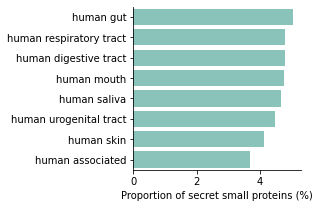

In [3]:
fig = plt.figure(figsize=(3, 3))
ax= sns.barplot(data=df,y='habitat',x='secret proportion',color='#80cdc1')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('')
plt.xlabel('Proportion of secret small proteins (%)')
plt.savefig(r'D:\GMSC\transmembrane\secret\figure\habitat_human.svg')

In [4]:
df = pd.read_csv(r'D:\GMSC\transmembrane\secret\90AA_human_secret_tax_summary_top.tsv',sep='\t',names=['habitat','phylum','number'])
df

,habitat,phylum,number
0,human gut,p__Firmicutes_A,640113
1,human skin,p__Actinobacteriota,32393
2,human gut,p__Bacteroidota,191433
3,human mouth,p__Actinobacteriota,20275
4,human gut,p__Proteobacteria,43673
...,...,...,...
58,human urogenital tract,p__Proteobacteria,343
59,human associated,p__Firmicutes_C,82
60,human associated,p__Firmicutes,384
61,human associated,Other,16


In [5]:
pivot_df = df.pivot(index='habitat', columns='phylum', values='number').fillna(0)
pivot_df

phylum,Other,p__Actinobacteriota,p__Bacteroidota,p__Firmicutes,p__Firmicutes_A,p__Firmicutes_C,p__Proteobacteria,p__Verrucomicrobiota
habitat,,,,,,,,
human associated,16.0,368.0,275.0,384.0,144.0,82.0,213.0,0.0
human digestive tract,673.0,1503.0,4291.0,2999.0,938.0,1506.0,822.0,2.0
human gut,27050.0,50502.0,191433.0,74726.0,640113.0,24392.0,43673.0,12633.0
human mouth,8353.0,20275.0,15080.0,9745.0,6641.0,6678.0,7625.0,19.0
human respiratory tract,2678.0,5698.0,9721.0,8818.0,3960.0,3157.0,3199.0,5.0
human saliva,4340.0,16508.0,14097.0,14318.0,5825.0,5412.0,5267.0,8.0
human skin,1310.0,32393.0,5145.0,9849.0,6733.0,1145.0,18598.0,100.0
human urogenital tract,130.0,717.0,672.0,428.0,247.0,120.0,343.0,3.0


In [6]:
pivot_percent = pivot_df.div(pivot_df.sum(axis=1), axis=0)
pivot_percent

phylum,Other,p__Actinobacteriota,p__Bacteroidota,p__Firmicutes,p__Firmicutes_A,p__Firmicutes_C,p__Proteobacteria,p__Verrucomicrobiota
habitat,,,,,,,,
human associated,0.010796,0.248313,0.185560,0.259109,0.097166,0.055331,0.143725,0.000000
human digestive tract,0.052851,0.118030,0.336972,0.235511,0.073661,0.118266,0.064552,0.000157
human gut,0.025410,0.047441,0.179830,0.070197,0.601315,0.022914,0.041026,0.011867
human mouth,0.112247,0.272455,0.202645,0.130953,0.089242,0.089739,0.102465,0.000255
human respiratory tract,0.071920,0.153024,0.261065,0.236814,0.106349,0.084784,0.085911,0.000134
human saliva,0.065983,0.250977,0.214322,0.217681,0.088559,0.082281,0.080076,0.000122
human skin,0.017403,0.430340,0.068351,0.130844,0.089448,0.015211,0.247074,0.001328
human urogenital tract,0.048872,0.269549,0.252632,0.160902,0.092857,0.045113,0.128947,0.001128


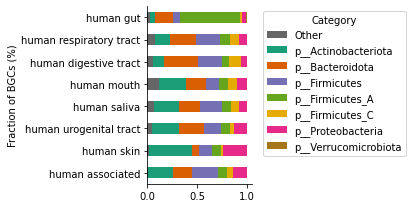

In [9]:
fig, ax = plt.subplots(figsize=(6, 3))
custom_colors = ['#666666','#1b9e77', '#d95f02', '#7570b3', '#66a61e', '#e6ab02', '#e7298a','#a6761d']
order = ['human associated','human skin','human urogenital tract','human saliva','human mouth','human digestive tract','human respiratory tract','human gut']
pivot_percent_sorted = pivot_percent.reindex(order)  
pivot_percent_sorted.plot(kind='barh', stacked=True,color=custom_colors,ax=ax)

ax.spines['right'].set_visible(False)

ax.spines['top'].set_visible(False)
plt.ylabel('Fraction of BGCs (%)')
#plt.xticks(rotation=45, ha='right')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(r'D:\GMSC\transmembrane\secret\figure\tax_human.svg')

In [6]:
df = pd.read_csv(r'D:\GMSC\transmembrane\secret\disease_top.csv')
df['Proportion'] = df['Proportion']*100
df = df.sort_values(by='Proportion',ascending=False)
df

,Disease,Proportion
9,CDI,5.733575
8,Nonalcoholic fatty liver disease,5.683693
7,atherosclerotic cardiovascular disease,5.451813
6,UC,5.443195
5,CRC,5.440048
4,CD,5.418875
3,T1D,5.232493
2,Schizophrenia,5.194837
1,ankylosing spondylitis,5.167232
0,RA,5.156376


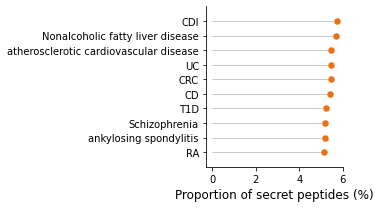

In [24]:
fig, ax = plt.subplots(figsize=(5, 3)) 

plt.hlines(y=df['Disease'], xmin=0, xmax=df['Proportion'], color='#525252', alpha=0.3, linewidth=1)

plt.scatter(df['Proportion'], df['Disease'],color='#ec7014', s=50, zorder=3, edgecolors='white', linewidths=0.5)

plt.xlabel('Proportion of secret peptides (%)', fontsize=12)
#plt.ylabel('Genus', fontsize=12)

#plt.yticks(fontsize=8) 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.ylim(len(df), -1) 

plt.tight_layout()
plt.savefig(r'D:\GMSC\transmembrane\secret\figure\disease_prop.svg')

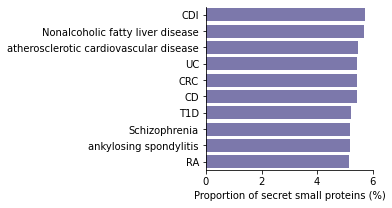

In [87]:
fig = plt.figure(figsize=(3, 3))
ax= sns.barplot(data=df,y='Disease',x='Proportion',color='#7570b3')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('')
plt.xlabel('Proportion of secret small proteins (%)')
plt.savefig(r'D:\GMSC\transmembrane\secret\figure\disease.svg')

In [93]:
df = pd.read_csv(r'D:\GMSC\transmembrane\secret\cdi/pfam.csv')
df['Proportion'] = df['Proportion']*100
#df = df.sort_values(by='Proportion',ascending=False)
df

,Pfam_ID,Proportion,Pfam,Clan_all
0,pfam16344,6.530409,DUF4974,NaN
1,pfam19127,6.380857,Choline_bind_3,Choline binding repeat superfamily
2,pfam00395,6.281156,SLH,NaN
3,pfam03793,3.539382,PASTA,NaN
4,pfam01476,3.364905,LysM,LysM-like domain
5,pfam01473,2.492522,Choline_bind_1,Choline binding repeat superfamily
6,pfam07338,2.442672,YdgH_BhsA-like,YdgH_BhsA-like
7,pfam08239,2.392821,SH3_3,Src homology-3 domain
8,pfam04977,2.243270,DivIC,FtsL
9,pfam00404,1.894317,Dockerin_1,EF_hand


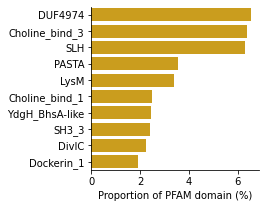

In [95]:
fig = plt.figure(figsize=(3, 3))
ax= sns.barplot(data=df,y='Pfam',x='Proportion',color='#e6ab02')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('')
plt.xlabel('Proportion of PFAM domain (%)')
plt.savefig(r'D:\GMSC\transmembrane\secret\figure\pfam.svg')

In [124]:
df = pd.read_csv(r'D:\GMSC\transmembrane\secret\cdi\cdi_90AA_habitat.tsv',sep='\t',header=None,names=['small protein family','habitat','count','all','proportion'])
df = df[['small protein family','habitat','proportion']]
df

,small protein family,habitat,proportion
0,GMSC10.90AA.287_201_268,human gut,0.645161
1,GMSC10.90AA.287_201_268,human saliva,0.322581
2,GMSC10.90AA.287_201_268,human mouth,0.258065
3,GMSC10.90AA.287_201_268,human respiratory tract,0.161290
4,GMSC10.90AA.287_201_268,human skin,0.032258
5,GMSC10.90AA.287_856_283,human gut,0.642857
6,GMSC10.90AA.287_856_283,human respiratory tract,0.071429
7,GMSC10.90AA.287_856_283,human skin,0.071429
8,GMSC10.90AA.287_856_283,human associated,0.047619
9,GMSC10.90AA.287_856_283,human urogenital tract,0.023810


In [125]:
df = df.pivot(columns='habitat',index='small protein family',values='proportion')
df

habitat,human associated,human digestive tract,human gut,human mouth,human respiratory tract,human saliva,human skin,human urogenital tract
small protein family,,,,,,,,
GMSC10.90AA.286_722_384,0.050000,NaN,0.650000,NaN,NaN,NaN,0.100000,NaN
GMSC10.90AA.286_862_263,NaN,NaN,0.590909,NaN,NaN,NaN,NaN,NaN
GMSC10.90AA.287_201_268,NaN,NaN,0.645161,0.258065,0.161290,0.322581,0.032258,NaN
GMSC10.90AA.287_437_554,NaN,NaN,0.525000,NaN,0.025000,NaN,0.025000,0.025000
GMSC10.90AA.287_469_144,NaN,0.025,0.650000,0.275000,0.100000,0.225000,0.025000,NaN
GMSC10.90AA.287_496_989,0.025641,NaN,0.589744,NaN,NaN,NaN,0.025641,NaN
GMSC10.90AA.287_584_849,0.018182,NaN,0.709091,NaN,0.018182,NaN,0.054545,0.018182
GMSC10.90AA.287_692_407,0.021739,NaN,0.608696,NaN,NaN,NaN,0.108696,NaN
GMSC10.90AA.287_856_283,0.047619,NaN,0.642857,NaN,0.071429,NaN,0.071429,0.023810


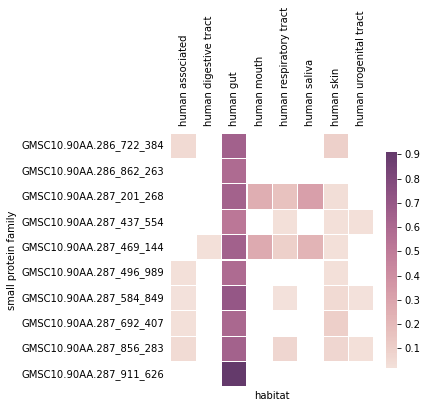

In [127]:
fig, ax = plt.subplots(figsize=(6, 6))
#sns.heatmap(df,square=True,cmap=sns.cubehelix_palette(dark=.3,light=0.9,as_cmap=True),linewidth=.1,xticklabels=False,yticklabels=False)
sns.heatmap(df,square=True,cmap=sns.cubehelix_palette(dark=.3,light=0.9,as_cmap=True),linewidth=.1, xticklabels=df.columns,yticklabels=df.index,cbar_kws={"shrink": 0.8})
#sns.heatmap(df,square=True,cmap=sns.cubehelix_palette(dark=.3,light=0.9,as_cmap=True),linewidth=.1, xticklabels=df.columns,yticklabels=df.index,cbar_kws={'orientation': 'horizontal',"shrink": 0.5})

ax.xaxis.tick_top()
ax.set_xticklabels(df.columns,rotation=90)

#ax.set_yticklabels('')
#ax.set(ylabel="")
#ax.set(xlabel="Proportion of samples\nper habitat")

ax.tick_params(left=False) 
ax.tick_params(top=False) 

plt.tight_layout()
plt.savefig(r'D:\GMSC\transmembrane\secret\figure\seq_habitat.svg',bbox_inches='tight')

In [128]:
df = pd.read_csv(r'D:\GMSC\transmembrane\secret\cdi\cdi_90AA_taxonomy.tsv',sep='\t',header=None,names=['small protein family','genus','presense'])
df

,small protein family,genus,presense
0,GMSC10.90AA.287_201_268,g__Streptococcus,1
1,GMSC10.90AA.287_856_283,g__Klebsiella,1
2,GMSC10.90AA.287_856_283,g__Salmonella,1
3,GMSC10.90AA.286_862_263,g__Lacticaseibacillus,1
4,GMSC10.90AA.286_862_263,g__Lactobacillus,1
5,GMSC10.90AA.286_722_384,g__Buttiauxella,1
6,GMSC10.90AA.286_722_384,g__Raoultella,1
7,GMSC10.90AA.286_722_384,g__Klebsiella,1
8,GMSC10.90AA.287_469_144,g__Streptococcus,1
9,GMSC10.90AA.287_496_989,g__Klebsiella,1


In [129]:
df = df.pivot(columns='genus',index='small protein family',values='presense')
df

genus,g__Buttiauxella,g__Klebsiella,g__Lacticaseibacillus,g__Lactobacillus,g__Phascolarctobacterium,g__Raoultella,g__Salmonella,g__Streptococcus
small protein family,,,,,,,,
GMSC10.90AA.286_722_384,1.0,1.0,NaN,NaN,NaN,1.0,NaN,NaN
GMSC10.90AA.286_862_263,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN
GMSC10.90AA.287_201_268,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
GMSC10.90AA.287_437_554,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN
GMSC10.90AA.287_469_144,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
GMSC10.90AA.287_496_989,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
GMSC10.90AA.287_584_849,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
GMSC10.90AA.287_692_407,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
GMSC10.90AA.287_856_283,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN


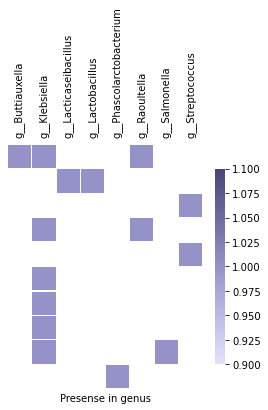

In [130]:
fig, ax = plt.subplots(figsize=(4.5, 4.5))
sns.heatmap(df,square=True,cmap=sns.cubehelix_palette(rot=0,dark=.3,light=0.9,as_cmap=True),linewidth=.1, xticklabels=df.columns,yticklabels=df.index,cbar_kws={"shrink": 0.8})
#sns.heatmap(fdata,square=True,cmap=sns.cubehelix_palette(rot=0,dark=.3,light=0.9,as_cmap=True),linewidth=.1, xticklabels=fdata.columns,yticklabels=fdata.index,cbar_kws={'orientation': 'horizontal',"shrink": 0.5})
ax.set(xlabel="Number of smORFs of Phylum")

ax.set_yticklabels('')
ax.set(ylabel="")
ax.set(xlabel="Presense in genus")

ax.xaxis.tick_top()
ax.set_xticklabels(df.columns,rotation=90)
ax.tick_params(left=False) 
ax.tick_params(top=False) 
plt.savefig(r'D:\GMSC\transmembrane\secret\figure\seq_genus.svg',bbox_inches='tight')

In [143]:
df = pd.read_csv(r'D:\GMSC\transmembrane\secret\cdi\enrich.csv')
df

,Pfam_ID,CDI_count,CDI_all,CTR_count,CTR_all,CDI_prop,CTR_prop,fold_change,p_fisher,p_chi2,p_adjusted_fisher,p_adjusted_chi2,Pfam
0,pfam07338,98,4012,2,1769,0.024427,0.001131,21.605434,1.430000e-13,7.690000e-10,6.460000e-11,3.480000e-07,YdgH_BhsA-like
1,pfam00395,252,4012,174,1769,0.062812,0.098361,0.638584,3.190000e-06,2.440000e-06,1.446832e-03,1.106456e-03,SLH
2,pfam00404,76,4012,60,1769,0.018943,0.033917,0.558508,9.050890e-04,7.583660e-04,4.100055e-01,3.435397e-01,Dockerin_1
3,pfam16344,262,4012,137,1769,0.065304,0.077445,0.843233,1.024054e-01,1.048312e-01,1.000000e+00,1.000000e+00,DUF4974
4,pfam19127,256,4012,99,1769,0.063809,0.055964,1.140175,2.593768e-01,2.777137e-01,1.000000e+00,1.000000e+00,Choline_bind_3
5,pfam03793,142,4012,52,1769,0.035394,0.029395,1.204070,2.674320e-01,2.766526e-01,1.000000e+00,1.000000e+00,PASTA
6,pfam01476,135,4012,54,1769,0.033649,0.030526,1.102318,5.748411e-01,5.925502e-01,1.000000e+00,1.000000e+00,LysM
7,pfam01473,100,4012,37,1769,0.024925,0.020916,1.191695,3.987489e-01,4.066690e-01,1.000000e+00,1.000000e+00,Choline_bind_1
8,pfam08239,96,4012,44,1769,0.023928,0.024873,0.962023,8.527980e-01,9.025248e-01,1.000000e+00,1.000000e+00,SH3_3
9,pfam04977,90,4012,41,1769,0.022433,0.023177,0.967889,8.483882e-01,9.367658e-01,1.000000e+00,1.000000e+00,DivIC


<ipython-input-148-17b6d626bc33>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='log(fold_change)', y="Pfam",palette=sns.color_palette(colors))


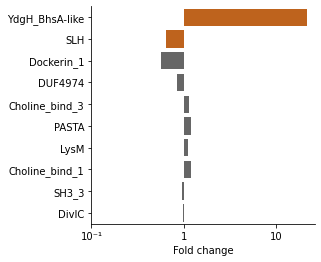

In [148]:
fig, ax = plt.subplots(figsize=(4,4))
df['log(fold_change)'] = df["fold_change"].apply(np.log10)
colors=['#d95f02','#d95f02','#666666','#666666','#666666','#666666','#666666','#666666','#666666','#666666']
sns.barplot(data=df, x='log(fold_change)', y="Pfam",palette=sns.color_palette(colors))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.xticks([-1,0,1],['10⁻¹','1','10'])
ax.set_xlabel('Fold change')
ax.set_ylabel('')
#plt.savefig(r'D:\GMSC\transmembrane\secret\figure\pfam_enrich.svg',bbox_inches='tight')
plt.savefig(r'D:\GMSC\transmembrane\secret\figure\seq_genus.png',bbox_inches='tight')

In [151]:
df = pd.read_csv(r'D:\GMSC\transmembrane\secret\human_gut_genus.csv',names = ['genus','count'])
df

,genus,count
0,g__Streptococcus,12783
1,g__Longicatena,4868
2,g__Erysipelatoclostridium,4104
3,g__Holdemanella,3258
4,g__Staphylococcus,2302
5,g__Lactobacillus,2145
6,g__Limosilactobacillus,1742
7,g__Holdemania,1715
8,g__CAG-460,1456
9,g__CAG-302,1406


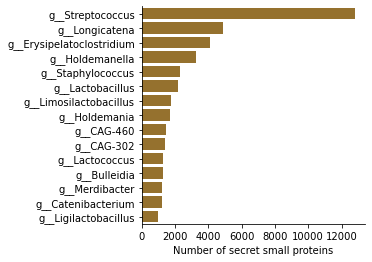

In [157]:
fig = plt.figure(figsize=(4, 4))
ax= sns.barplot(data=df,y='genus',x='count',color='#a6761d')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.ylabel('')
plt.xlabel('Number of secret small proteins')
plt.savefig(r'D:\GMSC\transmembrane\secret\figure\genus.svg',bbox_inches='tight')